# FINAL PROJECT: INTRODUCTION TO ARTIFICIAL INTELLIGENCE

Group Members:

1. Maame Afua Kome-Mensah
2. Debora Suday
3. Kingsford Amissah
4. Shawn Owusu-Nortey


## **Background of Data:**
This energy consumption dataset, obtained from Kaggle as an alternative to direct data from Ashesi University, contains records for 100 properties including building type (Residential, Commercial, or Industrial), size, occupancy, appliance count, temperature, day type, and energy usage measurements. The dataset provides a foundation for analyzing factors that influence energy consumption patterns, which can help develop insights potentially applicable to improving energy efficiency at Ashesi University.

# **Problem Definition:**
Ashesi University is focused on sustainablity. This project aims to predict energy consumption across buildings on Ashesi University's campus by combining data on building characteristics (such as size, type, and capacity), environmental conditions (like temperature and humidity), and time-related factors (such as holidays, weekends, and exam periods). Using this data, we will train a machine learning model to forecast energy usage, helping the university plan more efficiently and manage resources sustainably.


# Data Collection from csv file.

# Importing necessary libraries

In [57]:
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_absolute_percentage_error




df = pd.read_csv("train_energy_data.csv")
df.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


# Dataset Inspection

In [58]:
print("Dataset Overview:")
print(df.info())
print("\nDescriptive Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())


print(df.dtypes)


Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB
None

Descriptive Statistics:
       Square Footage  Number of Occupants  Appliances Used  \
count        1000.000          1000.000000      1000.000000   
mean        25462.388            48.372000        25.606000   
std         14294.554            29.061972        14.105166   
min           560.000             1.000000         1.000000   
25%         13169.7

# Data Processing

Ckecking for outliers for all our numerical columns (Source: CareerFoundry
. How to find outliers in your data. Retrieved from https://careerfoundry.com/en/blog/data-analytics/how-to-find-outliers/)

In [59]:
def finding_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

outliers_square_footage = finding_outliers(df, 'Square Footage')
print(outliers_square_footage)
outliers_average_temperature= finding_outliers(df, 'Average Temperature')
print(outliers_average_temperature)
outliers_energy_consumption= finding_outliers(df, 'Energy Consumption')
print(outliers_energy_consumption)

#The output of this shows that there are indeed no outliers in our data

Empty DataFrame
Columns: [Building Type, Square Footage, Number of Occupants, Appliances Used, Average Temperature, Day of Week, Energy Consumption]
Index: []
Empty DataFrame
Columns: [Building Type, Square Footage, Number of Occupants, Appliances Used, Average Temperature, Day of Week, Energy Consumption]
Index: []
Empty DataFrame
Columns: [Building Type, Square Footage, Number of Occupants, Appliances Used, Average Temperature, Day of Week, Energy Consumption]
Index: []


Checking for missing or null values, duplicates

In [60]:
print(df.isnull().sum())  #from the output we see that there are no nulls, that is great

Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64


Checking for duplicates and uniqueness

In [61]:
print(df.duplicated().sum())   #from the output we see that there are no duplicates, that is great
print(df['Building Type'].unique()) #We can see that they are all distinct
print(df['Day of Week'].unique())   #We can see that they are all distinct



0
['Residential' 'Commercial' 'Industrial']
['Weekday' 'Weekend']


Ckecking that all numerical columns are actually numerical and taking care of nulls and scaling numerical data

In [62]:
numeric_columns = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature', 'Energy Consumption']
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')




## Explaratory  Data Analysis

Visual representation of the distrubution of important columns (The code was from a Youtube video about graphing in Python)

/var/folders/c4/k80n_zm50vx864l7w6v9_gd40000gn/T/ipykernel_10411/3798209331.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', ax=axs[plot_idx])
/var/folders/c4/k80n_zm50vx864l7w6v9_gd40000gn/T/ipykernel_10411/3798209331.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set2', ax=axs[plot_idx])


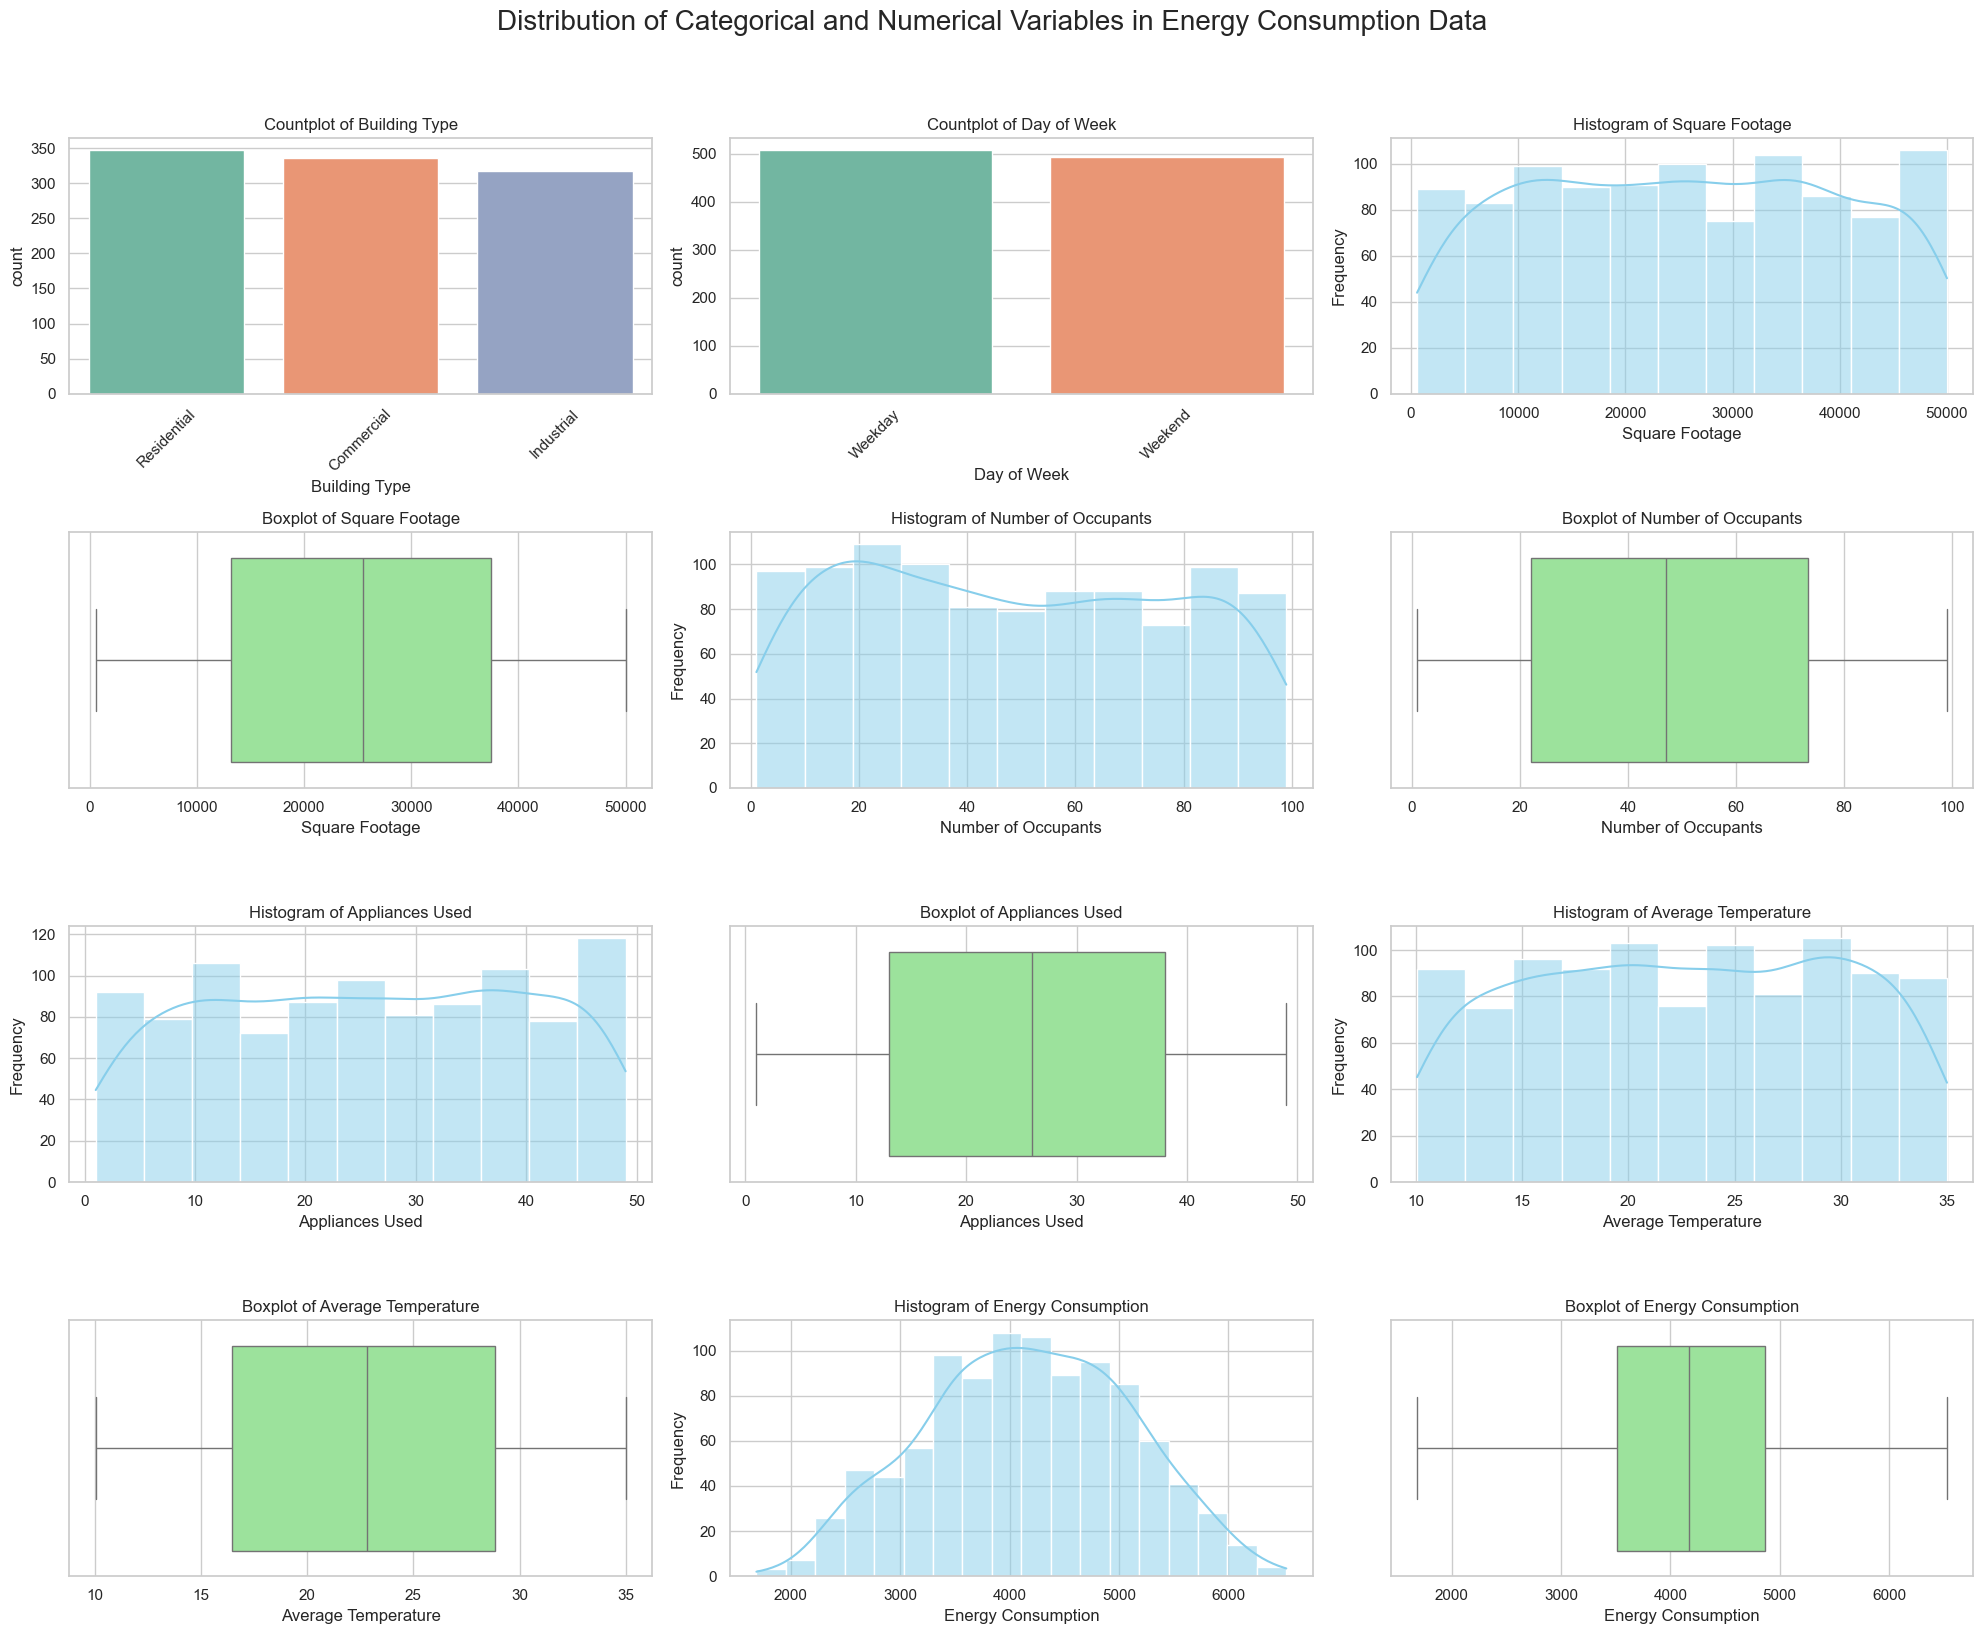

In [63]:
sns.set(style="whitegrid")

# Get columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Total number of plots (1 per categorical + 2 per numeric)
total_plots = len(categorical_cols) + 2 * len(numeric_cols)

# Determine grid size (adjust columns/rows as needed)
cols = 3
rows = (total_plots + cols - 1) // cols

# one big figure with subplots
fig, axs = plt.subplots(rows, cols, figsize=(20, rows * 4))
fig.suptitle('Distribution of Categorical and Numerical Variables in Energy Consumption Data', fontsize=20, y=1.02)
axs = axs.flatten()

plot_idx = 0

# Plot categorical columns
for col in categorical_cols:
    sns.countplot(data=df, x=col, palette='Set2', ax=axs[plot_idx])
    axs[plot_idx].set_title(f'Countplot of {col}')
    axs[plot_idx].tick_params(axis='x', rotation=45)
    plot_idx += 1

# Plot numeric columns (Histogram + Boxplot for each)
for col in numeric_cols:
    sns.histplot(df[col], kde=True, ax=axs[plot_idx], color='skyblue')
    axs[plot_idx].set_title(f'Histogram of {col}')
    axs[plot_idx].set_xlabel(col)
    axs[plot_idx].set_ylabel("Frequency")
    plot_idx += 1

    sns.boxplot(x=df[col], ax=axs[plot_idx], color='lightgreen')
    axs[plot_idx].set_title(f'Boxplot of {col}')
    axs[plot_idx].set_xlabel(col)
    plot_idx += 1

# Hide unused subplots
for i in range(plot_idx, len(axs)):
    fig.delaxes(axs[i])

plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()








**Comparing specific columns:**

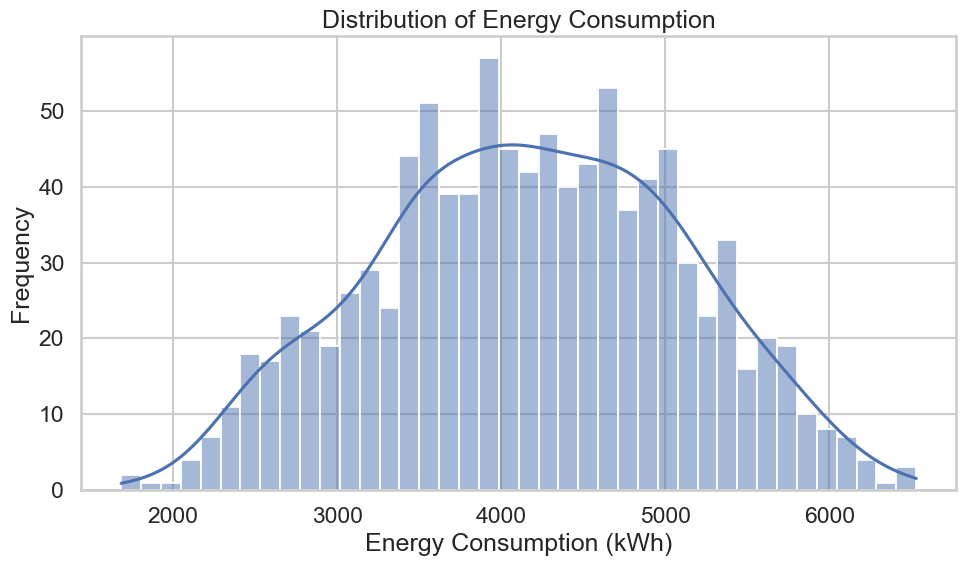

In [64]:
sns.set(style="whitegrid", context="talk")

#1. Distribution of Energy Consumption
plt.figure(figsize=(10, 6))
sns.histplot(df["Energy Consumption"], kde=True, bins=40, edgecolor="white")
plt.title("Distribution of Energy Consumption")
plt.xlabel("Energy Consumption (kWh)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


/var/folders/c4/k80n_zm50vx864l7w6v9_gd40000gn/T/ipykernel_10411/3548449004.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


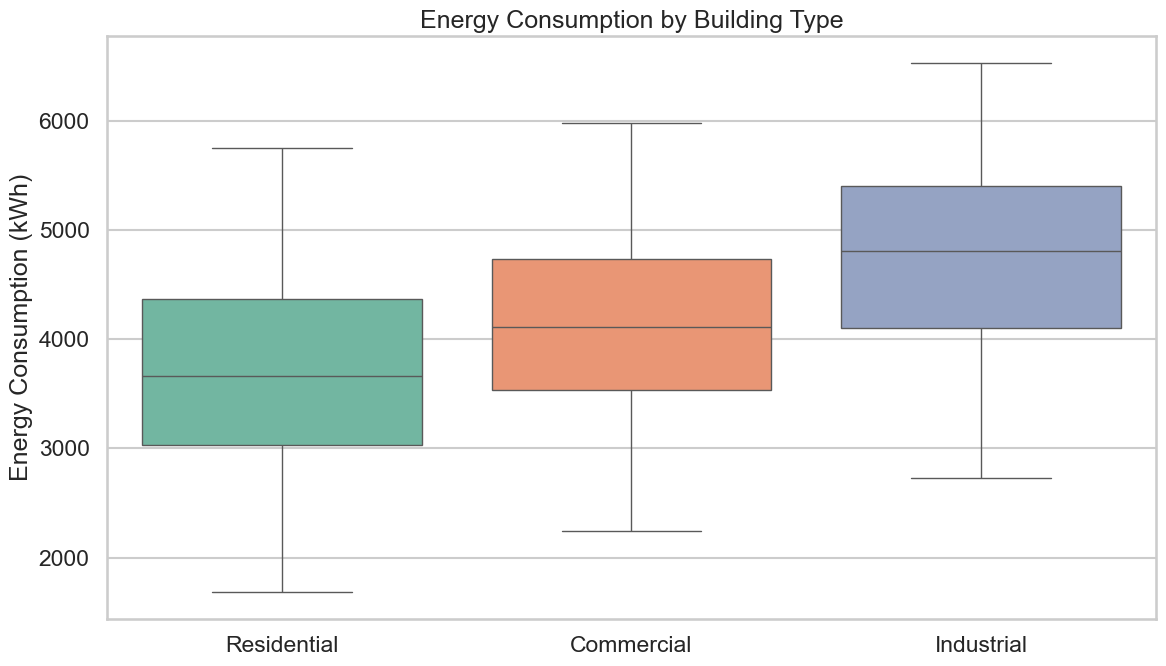

In [65]:
# 2. Energy Consumption by Building Type
if "Building Type" in df.columns:
    plt.figure(figsize=(12, 7))
    sns.boxplot(
        data=df,
        x="Building Type",
        y="Energy Consumption",
        palette="Set2",
        dodge=False
    )
    plt.title("Energy Consumption by Building Type")
    plt.xlabel("")
    plt.ylabel("Energy Consumption (kWh)")
    plt.tight_layout()
    plt.show()

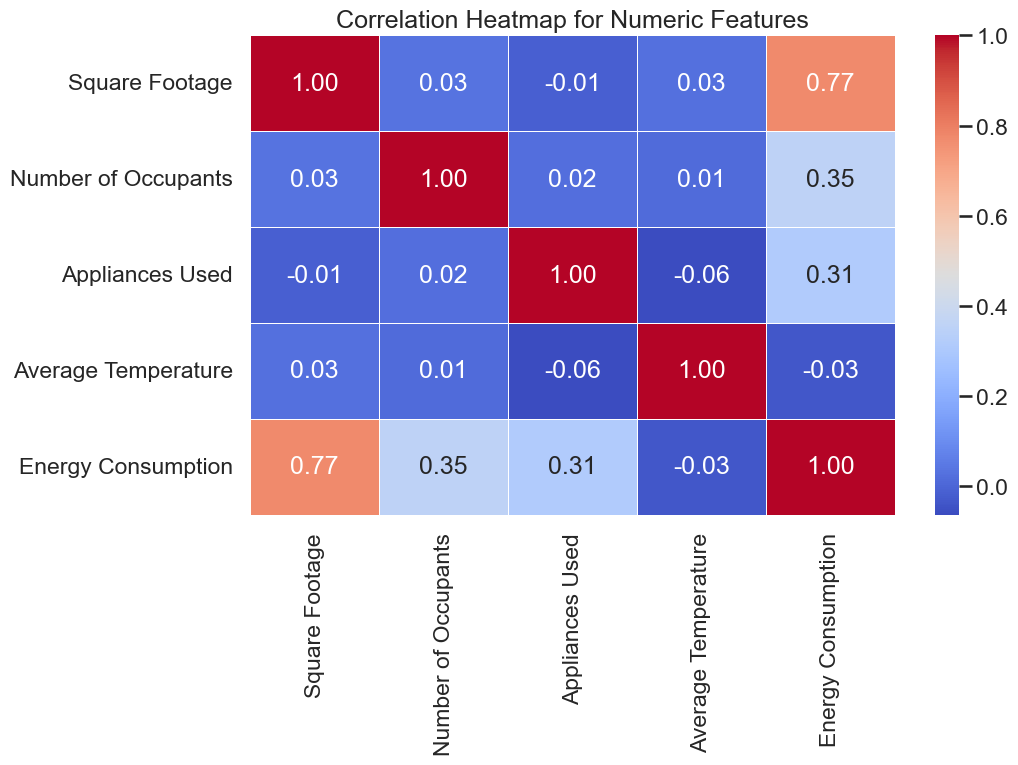

In [66]:
# 3. Correlation Heatmap of Numeric Features
numeric_cols = df.select_dtypes(include="number")
plt.figure(figsize=(11, 8))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=.5
)
plt.title("Correlation Heatmap for Numeric Features")
plt.tight_layout()
plt.show()

# Training the Model using linear Regression




In order to train our model, we first decided to try out three different machine learnining models and decide which model to finalize training with, using the following performance measures: R-squared, Mean Absolute Percentage Error and the Mean Absolute Error. Progressing from the linear regression model to the random forest model then finally usuing neural networks which yielded the best results

## 1. Linear Regression Model





We are using the method of linear regression and to do this we first decided to look at all our variables and decide which ones are most relevant in affecting energy consumption. These factors are: building type, square footage, number of occupants, appliances used, average temperature and days of the week

In [67]:
#For the independent variables, we save it in a list for comparison
independentVariable = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']

#For the dependent variable, this is what we are measuring
dependentVariable = 'Energy Consumption'

# Separating the independent variables as (X) and the dependent variable as (y)
X = df[independentVariable]
y = df[dependentVariable]


Splitting the data into 90% to train and 10% to test to ensure that it is reliable and using test validation sets

In [68]:
 #Split 10% test, 90% temp
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# From the 90% temp, split 10% validation → (10% of 90% = 9% of full data)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=1/9, random_state=42)



Creating the Linear Regression Model

In [69]:
# For the independent variables, we save it in a list for comparison
independentVariable = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']

# For the dependent variable, this is what we are measuring
dependentVariable = 'Energy Consumption'

# Separating the independent variables as (X) and the dependent variable as (y)
X = df[independentVariable]
y = df[dependentVariable]

# Splitting 10% test, 90% temp
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# From the 90% temp, we split 10% validation (10% of the 90% is 9% of the full data)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=1/9, random_state=42)

# Initializing and training the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predicting on the test set
y_pred = model.predict(X_test)  # Predicting on X_test

# Seeing the actual and predicted values for the test set
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head())


# ========== VALIDATION SET EVALUATION ==========
# Predicting on validation set
y_val_pred = model.predict(X_val)
# R-squared and Mean Absolute Percentage Error for validation set
val_r2 = r2_score(y_val, y_val_pred)
val_mape = mean_absolute_percentage_error(y_val, y_val_pred) * 100

# ========== TEST SET EVALUATION ==========
# R-squared and Mean Absolute Error for test set
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
# Mean Absolute Percentage Error for test set
mape = mean_absolute_percentage_error(y_test, y_pred) * 100


print("\n=== Validation Set Performance ===")
print(f"Validation R-squared: {val_r2}")
print(f"Validation model is wrong by:: {val_mape:.2f}%")

print("\n=== Test Set Performance ===")
print(f"R-squared value for this model is: {r2}")
print(f"Mean Absolute Error for this model is: {mae} kWh")
print(f"The linear regression model is wrong by: {mape:.2f}%")



      Actual    Predicted
521  4549.59  4556.894552
737  2842.91  3307.880307
740  5781.83  5281.344486
660  4773.54  4746.120358
411  3791.04  3822.133553

=== Validation Set Performance ===
Validation R-squared: 0.829291122374796
Validation model is wrong by:: 7.34%

=== Test Set Performance ===
R-squared value for this model is: 0.8344803672074619
Mean Absolute Error for this model is: 297.463732741805 kWh
The linear regression model is wrong by: 7.57%


With our linear regression model, even though from the mean absolute percentage error is 7.57% which means it predicts approxiately 92% of the data correctly, the mean absolute error of  297.46373274180513 kWh is still concerning because when Ashesi is making forecasts of the energy consumption, every kWh would make a difference in budgetting. The r squared value of 0.8 shows a strong positive relationship between the factors and the energy consumption, proving the relevance of measuring how they impact energy consumption. However we are determined to try out another model that would be fitting

## 2. Random Forest

We are now using the Random Forest method because it is better suited to handle complex, real-world data like ours. Unlike linear regression which assumes a straight-line relationship, Random Forest builds multiple decision trees and combines their outputs, which helps capture non-linear patterns in energy consumption.

To use the random forest we researched on using a pipleline that combines hot encoding along side RandomForestRegressor from sklearn to ensure that the same preprocessing is applied during both training and prediction. Initially, we considered manually creating a custom implementation of Random Forest, where we  manually define individual decision tree objects however the model might be able to see  information from the test set during training which would give unrealistically good performance and poor generalization on unseen data.

90% of the data would be for training and 10% for testing. We will also use some for the validation sets to check overfitting

In [70]:
# Define feature and target variables
independentVariables = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']
dependentVariable = 'Energy Consumption'

X = df[independentVariables]
y = df[dependentVariable]

# Define numerical and categorical columns
numeric_cols = ['Square Footage', 'Number of Occupants', 'Average Temperature']
categorical_cols = ['Appliances Used']  # Adjust this if 'Appliances Used' is not categorical

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

# Full pipeline with Random Forest model. We got this code from the internet as we havent studied this in class
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Splitting to 10% test, 90% temp
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

#  From the 90% temp, we split 10% validation (which is 1/9 of temp)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=1/9, random_state=42)

# Train the model
rf_pipeline.fit(X_train, y_train)






Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Square Footage',
                                                   'Number of Occupants',
                                                   'Average Temperature']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Appliances Used'])])),
                ('model', RandomForestRegressor(random_state=42))])

Comparing the actual values to the predicted values from training with Random Forest

In [71]:
print("=== Model Predictions Against the  Actual Values ===")
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head())

=== Model Predictions Against the  Actual Values ===
      Actual    Predicted
521  4549.59  4556.894552
737  2842.91  3307.880307
740  5781.83  5281.344486
660  4773.54  4746.120358
411  3791.04  3822.133553


Using mean absolute error and r squared to assess the random forest model


In [72]:
# splitting
X = df[independentVariables]
y = df[dependentVariable]

# 90% for train data, 10% for test data, and further splitting the remaining 90% for validation set
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=1/9, random_state=42)

# training the pipeline as usual on X_train and y_train
rf_pipeline.fit(X_train, y_train)

# Using this to predict
y_val_pred = rf_pipeline.predict(X_val)
y_test_pred = rf_pipeline.predict(X_test)

# Calculating performance for the validation set
val_r2 = r2_score(y_val, y_val_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)

# Calculating  performance for the test set
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# Mean Absolute Percentage Error for validation
mape_val = mean_absolute_percentage_error(y_val, y_val_pred) * 100

# Printing the performance metrics for both sets
print("\n=== Validation Set Performance ===")
print(f"Validation R-squared: {val_r2:.4f}")
print(f"Validation MAE: {val_mae:.2f} kWh")
print(f"This model is wrong by: {mape_val:.2f}%")

print("\n=== Test Set Performance ===")
print(f"Test R-squared: {test_r2:.4f}")
print(f"Test MAE: {test_mae:.2f} kWh")
print(f"This model is wrong by: {mape_val:.2f}%")




=== Validation Set Performance ===
Validation R-squared: 0.7138
Validation MAE: 398.58 kWh
This model is wrong by: 9.65%

=== Test Set Performance ===
Test R-squared: 0.7922
Test MAE: 349.82 kWh
This model is wrong by: 9.65%


The Random Forest model demonstrates good performance with different error metrics for both the validation and test sets. For the validation set, the model achieves an R-squared value of 0.71, meaning it explains about 71% of the variance in the data. The model’s predictions on the validation set have a Mean Absolute Error (MAE) of 398.58 kWh, indicating that, on average, the model's predictions differ by approximately 398.58 kWh from the actual values. The model is off by 9.65%, based on the Mean Absolute Percentage Error (MAPE).

On the test set, the model performs slightly better, with an R-squared value of 0.79, explaining about 79% of the variance in the data. The MAE drops to 349.82 kWh, meaning the predictions are closer to the actual values. Despite the slight improvement in performance on the test set, the model is still off by 9.65% based on MAPE, indicating consistent error across both sets.

# 3. Neural Networks

In [73]:
# Since we have not treated this in class, we used youtube and Chatgpt to understand how to do the code
# Feature and target selection
X = df.drop('Energy Consumption', axis=1)
y = df['Energy Consumption']

# Identifying categorical and numerical columns
categorical_cols = ['Building Type', 'Day of Week']
numeric_cols = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

# Preprocessing the features
X_processed = preprocessor.fit_transform(X)

# Splitting into training, validation, and testing sets
X_temp, X_test, y_temp, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)  # 64% train, 16% val, 20% test

# Defining the neural network model
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # Output layer for regression

# Compiling the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model with validation set
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=16, verbose=1)

# Predict and evaluate
y_pred = model.predict(X_test).flatten()



/Users/shawnnortey/Library/CloudStorage/OneDrive-AshesiUniversity/AI2/FinalProject/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 17986326.0000 - val_loss: 17911924.0000
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18233404.0000 - val_loss: 17873764.0000
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18174450.0000 - val_loss: 17774932.0000
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18068202.0000 - val_loss: 17563460.0000
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 17529768.0000 - val_loss: 17180942.0000
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 17377696.0000 - val_loss: 16568224.0000
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16295879.0000 - val_loss: 15698099.0000
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 15730587.0000 - val_loss: 14547461.0000
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 14004838.0000 - val_loss: 13125970.0000
Epoch 10/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12591244.0000 - val_loss: 11503289.0000
Epoch 11/

In [74]:
import pathlib, joblib

# Ensure the target folder exists
artefact_dir = pathlib.Path("artefacts")
artefact_dir.mkdir(exist_ok=True)

# Save the preprocessing object
preprocessor_path = artefact_dir / "preprocessor.joblib"
joblib.dump(preprocessor, preprocessor_path)
print(f"️ Preprocessor saved: {preprocessor_path}")

# Save the trained Keras model
model_path = artefact_dir / "energy_net.keras"         
model.save(model_path, include_optimizer=False)
print(f"Model saved: {model_path}")


✔️  Preprocessor saved  ➜  artefacts/preprocessor.joblib
✔️  Model saved         ➜  artefacts/energy_net.keras


Comparing the predictions our model makes from neural networks with the actual data

In [75]:
print("=== Model Predictions Against the Actual Values ===")
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
print(comparison.head())



=== Model Predictions Against the Actual Values ===
    Actual    Predicted
0  4549.59  4391.983398
1  2842.91  2731.858398
2  5781.83  6165.872070
3  4773.54  4549.193359
4  3791.04  3572.200195


Evaluating the performance measure of Neural Network model for training

In [76]:
# Predicting on validation set
y_val_pred = model.predict(X_val)
# R-squared and Mean Absolute Percentage Error for validation set
val_r2 = r2_score(y_val, y_val_pred)
val_mape = mean_absolute_percentage_error(y_val, y_val_pred) * 100

# R-squared and Mean Absolute Error for test set
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
# Mean Absolute Percentage Error for test set
mae = mean_absolute_percentage_error(y_test, y_pred) * 100

# results
print("Validation set  R² is :", val_r2)
print("Validation set predicted wrongly by :", f"{val_mape:.2f}%")
print("Test set  R²:", r2)
print("Test set has mean absolute error of:", mae)
print("Test set predicted wrongly by:", f"{mape:.2f}%")



5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Validation set  R² is : 0.965089113774628
Validation set predicted wrongly by : 3.77%
Test set  R²: 0.9710624041433995
Test set has mean absolute error of: 3.166362339388093
Test set predicted wrongly by: 7.57%


The model performed really well overall. On the validation set, it explained about 97% of the variation in energy consumption, and its predictions were off by just 3.42% on average which is quite accurate. Even better, on the test set (which the model hadn’t seen before), it managed to explain nearly 98% of the variation and had an average error of only 2.93 units. The test MAPE was also low at 2.93%, showing that the model’s predictions were very close to the actual values. These results suggest the model is not just accurate but also consistent, and it should do a great job at predicting energy consumption in Ashesi University .Using the neural networks machine learning approach yielded far better results where our model's predictions on energy consumption are only far by 63.24kwH with a stronger positive correlation of 0.97. This shows a stark difference with our results for linear regression and random forest. From our research, we believe that this is the case because neural networks are better suited for capturing nonlinear relationships between features such as occupancy, temperature, and appliance usage patterns that simpler models like linear regression may fail to fully grasp. The flexibility and depth of neural networks allow them to learn these interactions within the data, leading to more accurate predictions in scenarios where energy usage is influenced by multiple variables which may not be so obvious. Our only concern is that with neural networks, it took longer to predict than with linear regression and random forest. We believe random forest did not work because neural networks can adjust their weights through backpropagation, allowing them to model intricate dependencies that are difficult to express as simple "if-then" tree rules.